In [2]:
using Markdown
using InteractiveUtils
using NonlinearSolve
using StaticArrays
# files
using PKAssetPrices
import PKAssetPrices.Static: Parametrization, Model
using CairoMakie 
using OrderedCollections


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [13]:
sols  = OrderedDict(
    "Baseline" => solve_model(Static.AssetPKPQ),
    "PQCr"   => solve_model(Static.AssetPKPQCr),
    "PQC"   => solve_model(Static.AssetPKPQC),
    "PQCrDiff"   => solve_model(Static.AssetPKPQCrDIFF),
    "PQA" => solve_model(Static.AssetPKPQA)
)

OrderedDict{String, PKAssetPrices.Static.Solution} with 5 entries:
  "Baseline" => Solution(16 vars, 3 sheets)
  "PQCr"     => Solution(17 vars, 3 sheets)
  "PQC"      => Solution(17 vars, 3 sheets)
  "PQCrDiff" => Solution(17 vars, 3 sheets)
  "PQA"      => Solution(17 vars, 3 sheets)

### Plot Differences

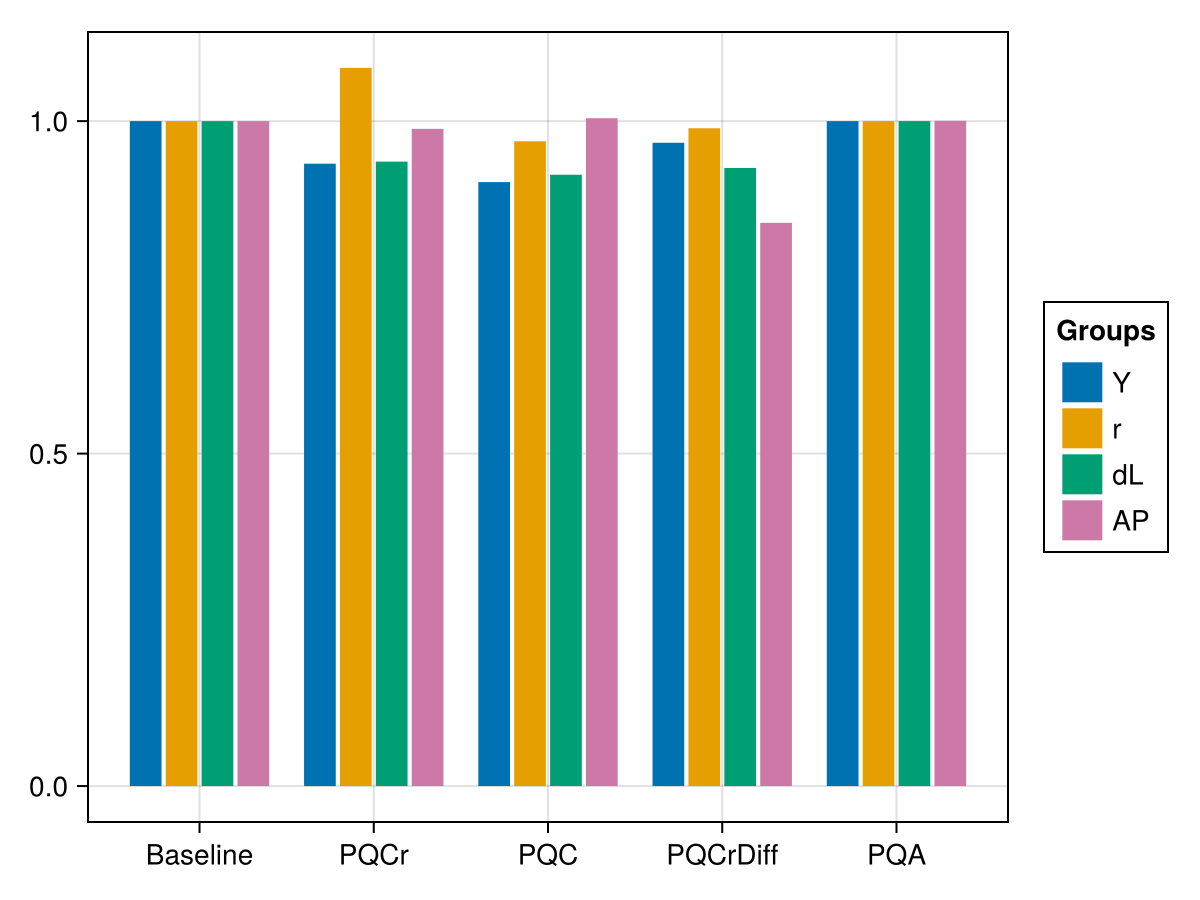

In [17]:
Static.bar_chart(sols, [:Y,:r, :dL,:AP])

In [18]:
Static.build_table_from_solutions(values(sols) |> collect, ["Baseline", "PQCr","PQC", "PQCrDiff", "PQA"])

Variable,Scenario 1: Baseline,Scenario 2: PQCr,Scenario 3: PQC,Scenario 4: PQCrDiff,Scenario 5: PQA
Y,6.566017914628954,6.145636776401819,5.96394779216177,6.352449637008641,6.566017914628955
ND,3.283008957314477,3.0728183882009095,2.981973896080885,3.1762248185043207,3.2830089573144776
D,4.103761196643096,4.032043822151066,4.130939444731428,4.1134019534525805,4.103761196643096
i,0.09741726123444606,0.10521262802705805,0.09446310383354041,0.09636935288558905,0.09741726123444606
r,0.11202985041961297,0.12099452223111674,0.10863256940857147,0.1108247558184274,0.11202985041961298
P,1.7483452246889213,1.7070918223242317,1.6892620766708082,1.7273870577117811,1.7483452246889215
dL,3.6699681469484218,3.4464433871267737,3.3740268388672194,3.4113806093157173,3.6701309346369446
dM,3.6699681469484218,3.4464433871267737,3.3740268388672194,3.4113806093157173,3.6701309346369446
dR,1.1009904440845264,1.033933016138032,1.0122080516601657,1.0234141827947152,1.1010392803910833
W,1.9003752442270885,1.8555345894828608,1.8361544311639222,1.8775946279475884,1.9003752442270887


### Get Balance Sheets

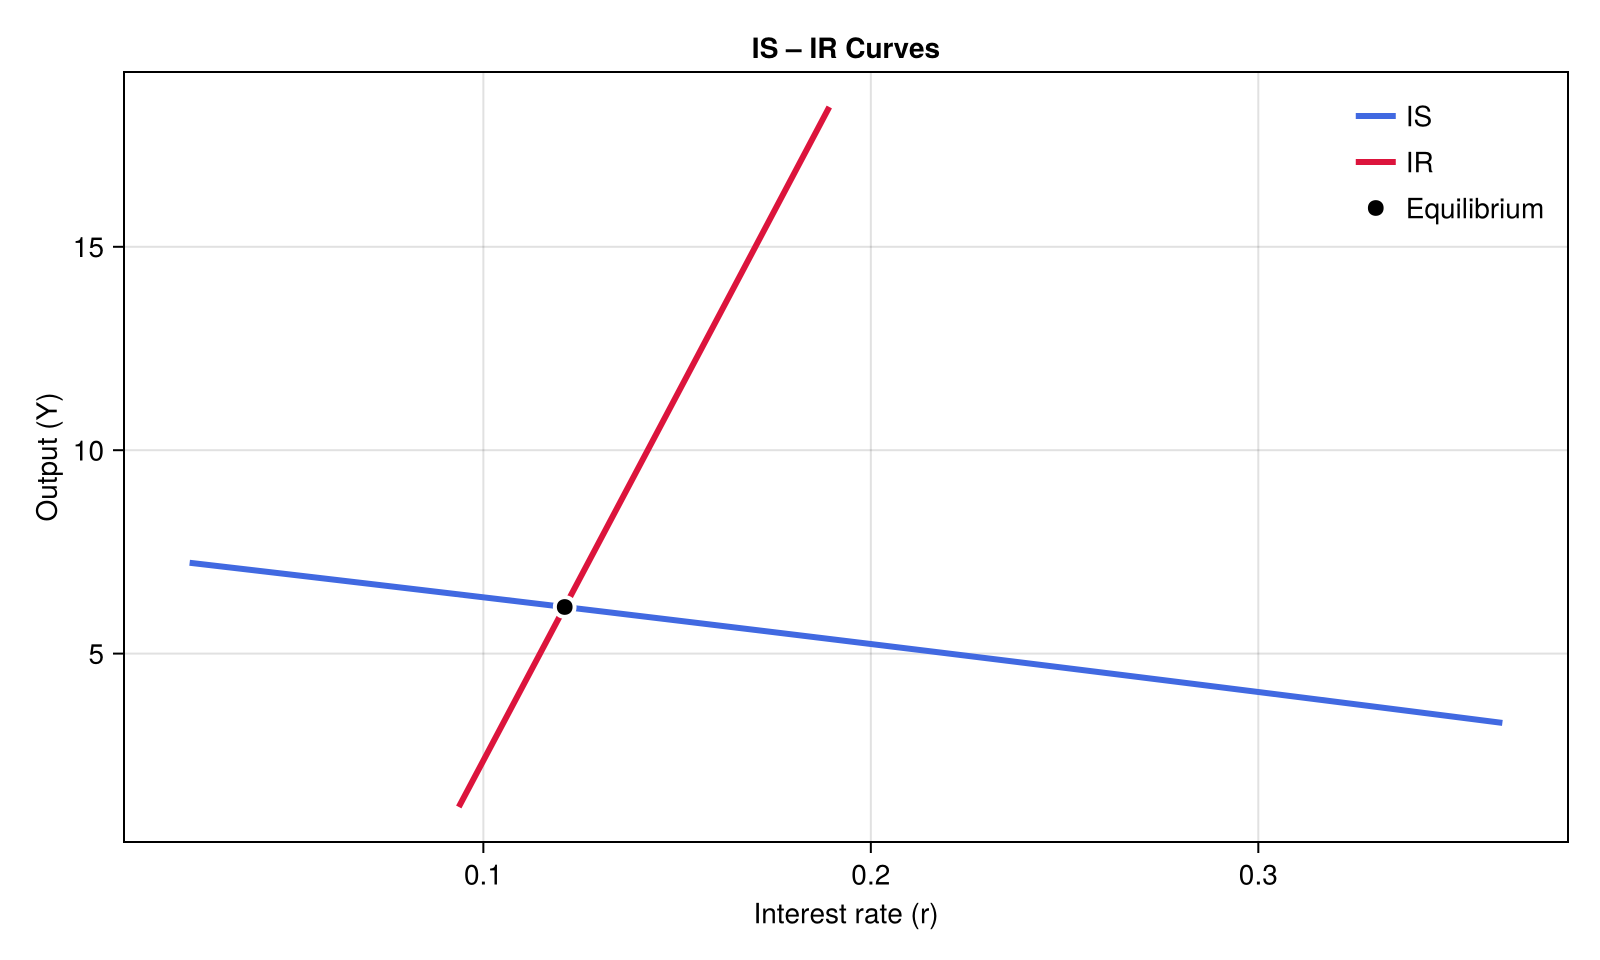

In [16]:
Static.is_ir_component(sols["PQCr"]) 

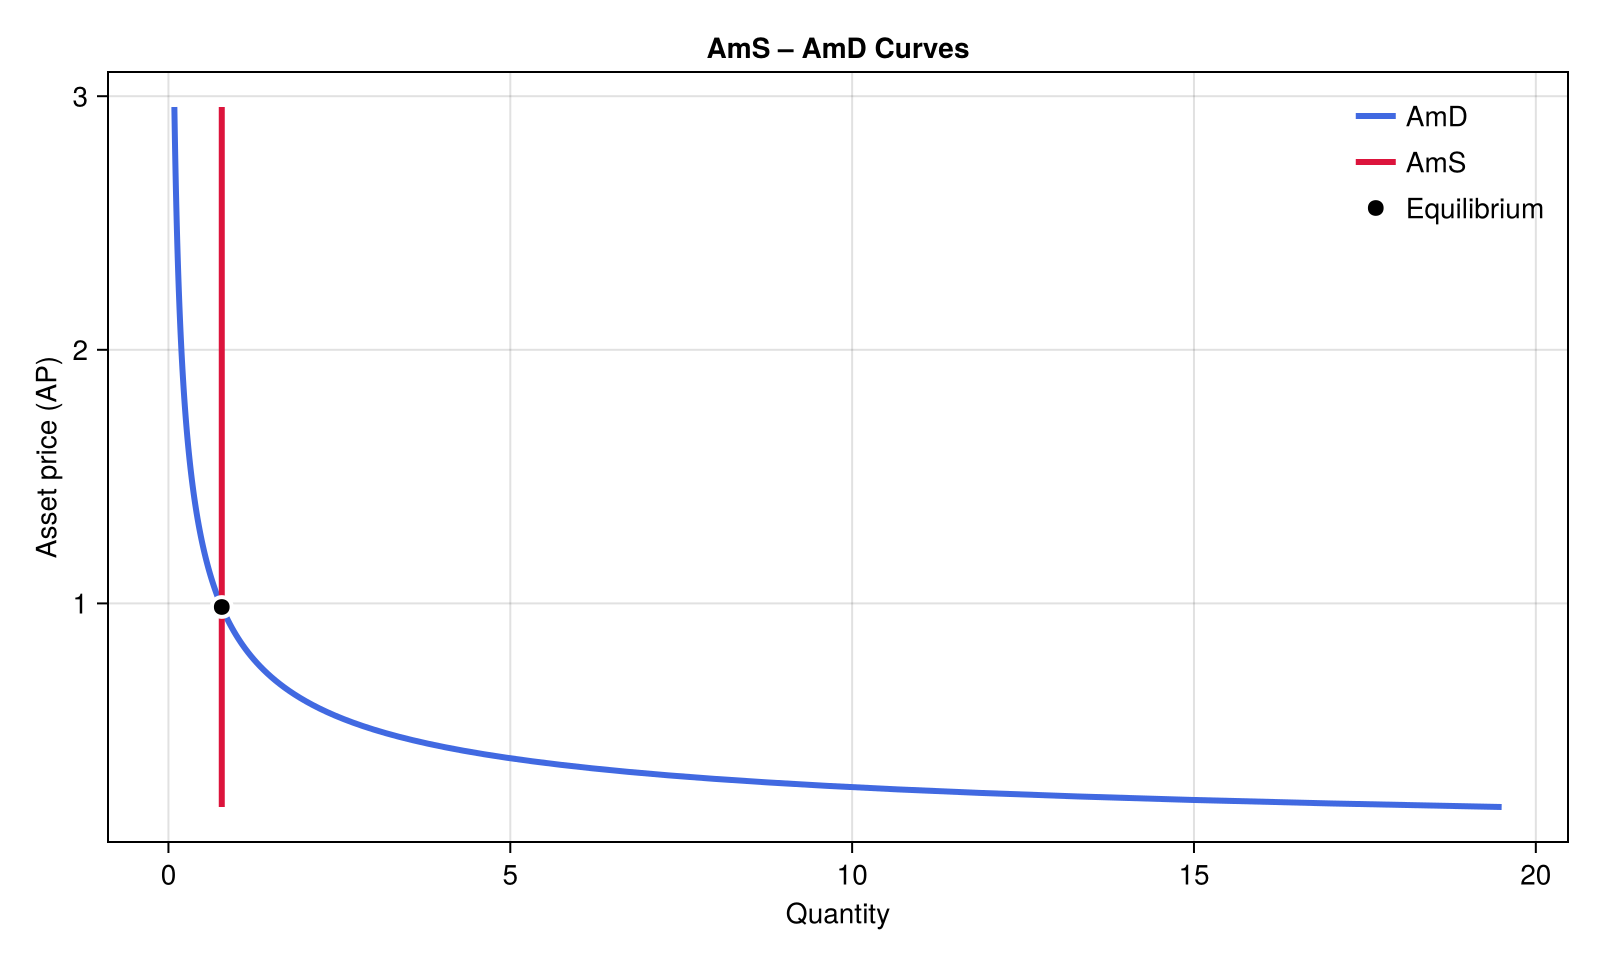

In [11]:

Static.ad_as_component(sols["PQCr"]) 


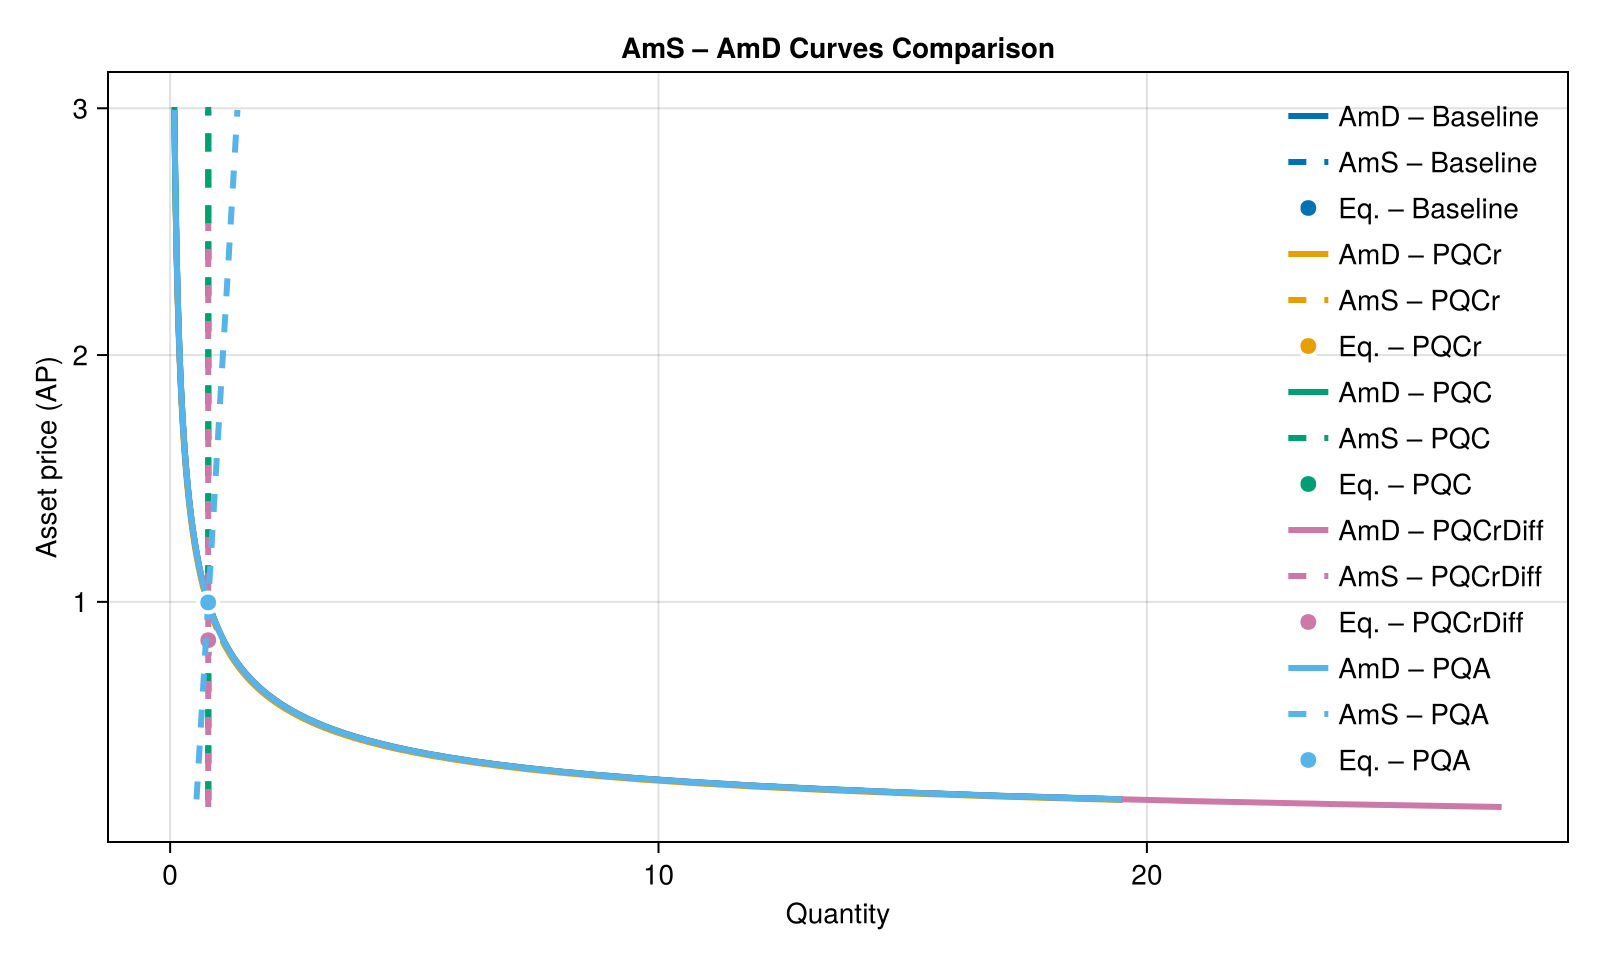

In [8]:
Static.ad_as_comparison_component([sols["Baseline"], sols["PQCr"], sols["PQC"], sols["PQCrDiff"], sols["PQA"]], ["Baseline", "PQCr","PQC", "PQCrDiff", "PQA"])